# Code Challenge: Unfortunate Starting Point

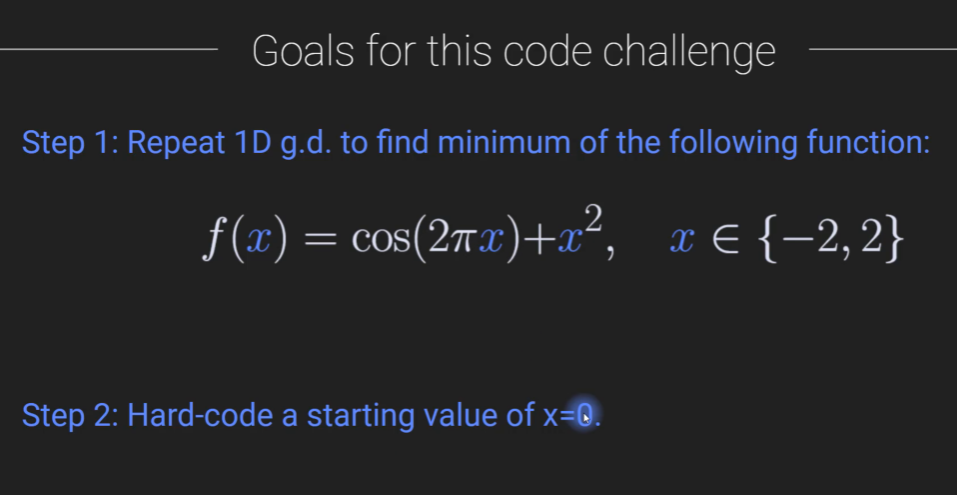

### Python Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import sympy as sp

matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'png')  

## Use Symbolic Derivatie to Determine derivative of this function:

In [16]:
# function ( as a function) as well as its derivative 
# x = 

x_sym = sp.symbols('x')

def f(x):
    return sp.cos(2*sp.pi*x_sym) + x_sym**2

def deriv(x):
    return sp.diff(f(x_sym), x_sym)

x = np.linspace(-2, 2, 2001)

In [26]:
f(x)

x**2 + cos(2*pi*x)

In [27]:
deriv(x)

2*x - 2*pi*sin(2*pi*x)

In [23]:
f_func=sp.lambdify(x_sym, f(x_sym), 'numpy')
deriv_func=sp.lambdify(x_sym, deriv(x_sym), 'numpy')


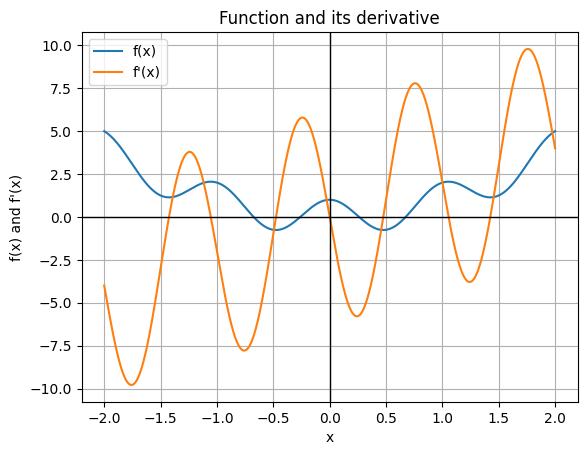

In [24]:
# plot the function and its derivative
plt.plot(x, f_func(x))
plt.plot(x, deriv_func(x))
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
# plt.xlim(-2, 2)
# plt.ylim(0, 10)
plt.xlabel('x')
plt.ylabel('f(x) and f\'(x)')
plt.title('Function and its derivative')
plt.legend(['f(x)', 'f\'(x)'])
plt.grid()
plt.show()

In [28]:
# gradient descent

#randomly select a point on the x-axis
localmin = np.random.choice(x, 1)
print(f'initial point: {localmin}')
# learning parameters
learning_rate = 0.01
training_epochs = 100

# run through training steps
for step in range(training_epochs):
    # compute the gradient at the current point
    grad = deriv_func(localmin)
    
    # update the point using the gradient and learning rate
    localmin = localmin - learning_rate * grad

localmin


initial point: [-1.934]


array([-1.42506741])

In [47]:
# gradient descent

#randomly select a point on the x-axis
localmin = 0
print(f'initial point: {localmin}')
# learning parameters
learning_rate = 0.01
training_epochs = 100

# run through training steps
for step in range(training_epochs):
    # compute the gradient at the current point
    grad = deriv_func(localmin)
    
    # update the point using the gradient and learning rate
    localmin = localmin - learning_rate * grad

localmin


initial point: 0


np.float64(0.0)

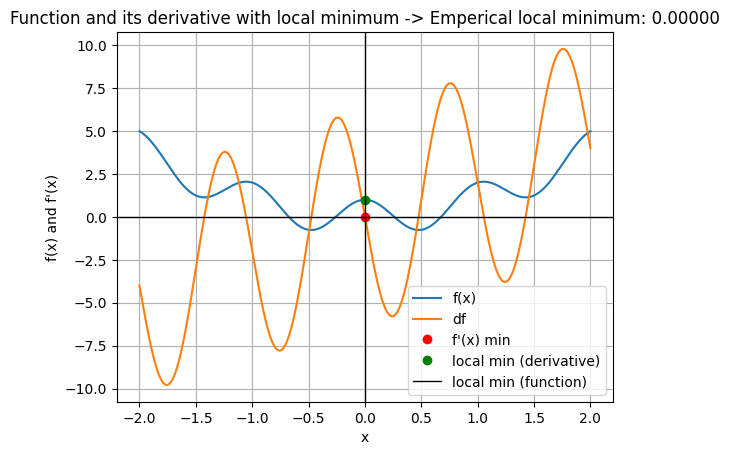

In [49]:
# plot the results
plt.plot(x, f_func(x), x, deriv_func(x))
plt.plot(localmin, deriv_func(localmin), 'ro')
plt.plot(localmin, f_func(localmin), 'go')

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
# plt.xlim(-2, 2)

# plt.ylim(-15, 30)
plt.xlabel('x')
plt.ylabel('f(x) and f\'(x)')
plt.title('Function and its derivative with local minimum -> Emperical local minimum: %.5f'%localmin)
plt.legend(['f(x)','df', 'f\'(x) min', 'local min (derivative)', 'local min (function)'])
plt.grid()
plt.show()  

In [43]:
# Store the model parameters and outputs on each iteration

# random starting point
localmin = np.random.choice(x, 1)
print(f'initial point: {localmin}')

# learning parameters
learning_rate = 0.005
training_epochs = 100

# run through training steps and store the model parameters and outputs on each iteration
modelparams = np.zeros((training_epochs, 2)) # columns for localmin, f(localmin), deriv(localmin)

for step in range(training_epochs):
    grad = deriv_func(localmin)
    localmin = localmin - learning_rate * grad  
    modelparams[step, :] = localmin[0], grad[0]


initial point: [0.788]


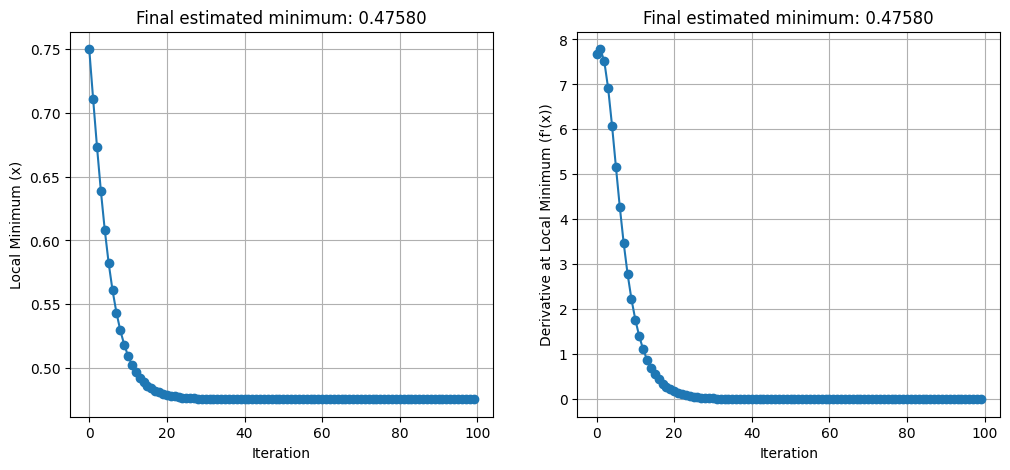

In [44]:
# plot the gradient descent over iterations
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for i in range(2):
    ax[i].plot(modelparams[:, i], marker='o')
    ax[i].set_xlabel('Iteration')
    ax[i].set_title('Final estimated minimum: %.5f'%localmin[0])
    
ax[0].set_ylabel('Local Minimum (x)')
ax[1].set_ylabel('Derivative at Local Minimum (f\'(x))')
ax[0].grid()
ax[1].grid()
plt.show() 


### Additional explorations

In [45]:
# 1) Modify the code so that training ends when the derivative is smaller than some threshold (e.g., 0.01) instead of a fixed number of epochs. Make sure the code is robust for negative derivates.

# random starting point
localmin = np.random.choice(x,1)
grad_threshold = 0.001
grad = deriv_func(localmin)

xi = np.array([localmin, grad])


while np.abs(grad) > grad_threshold:
    localmin = localmin - learning_rate * grad
    grad = deriv_func(localmin)
    xi = np.append(xi,[localmin, grad]) 

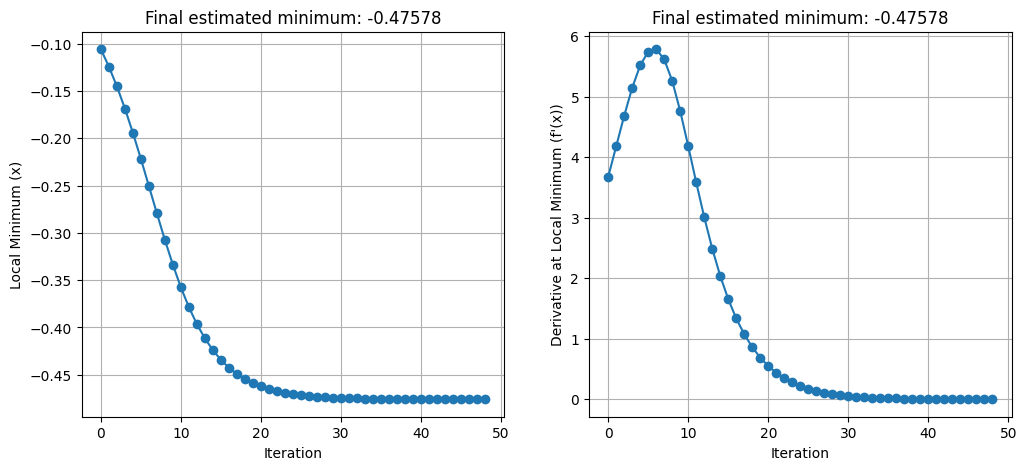

In [46]:
# plot the gradient descent over iterations
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
iterations = np.arange(len(xi) // 2)
ax[0].plot(iterations, xi[0::2], marker='o')
ax[0].set_xlabel('Iteration')
ax[0].set_ylabel('Local Minimum (x)')
ax[0].set_title('Final estimated minimum: %.5f'%localmin[0])
ax[1].plot(iterations, xi[1::2], marker='o')
ax[1].set_xlabel('Iteration')
ax[1].set_ylabel('Derivative at Local Minimum (f\'(x))')
ax[1].set_title('Final estimated minimum: %.5f'%localmin[0])
ax[0].grid()
ax[1].grid()
plt.show()

In [ ]:
# 2) no it does not 

In [ ]:
# 3) with the gradient stopping criterion, gradient descent can stuck in local minima, due to vanishing gradients, be affected by exploding gradients, infinite runs due to slow learning progress